# A3: Foundation Foods Pareto Analysis

**Input:** foundation_analysis_ready.csv (output of A1)

**Output:** foundation_pareto_front.csv

**Purpose:** Identify Pareto-optimal whole foods that minimize CO2 and price
while maximizing protein density. Includes sensitivity analysis across four
weighting schemes.


## Methodology

### Overview
This notebook identifies **Pareto-optimal** whole foods — foods where no other food is simultaneously cheaper, lower in CO2, and higher in protein. A food is Pareto-optimal if improving any one objective would require sacrificing at least one other. The result is not a single "best" food but a frontier of optimal trade-offs.

### Functional Unit: per 1000 kcal
All three objectives are expressed per 1000 kcal rather than per kg of food. This is the critical design choice: comparing CO2 and price per kg would systematically disadvantage water-rich foods (vegetables, fish) relative to calorie-dense ones (oils, nuts). The functional unit normalizes for energy contribution — every food is evaluated on the question *"what does it cost in money, CO2, and protein to get 1000 kcal from this food?"*

### Pareto Dominance
Before computing dominance, all objectives are min-max normalized to [0, 1] so that differences in scale (CO2: 0.3–45 kg; price: 0.5–30 $/1000 kcal; protein: 0–150 g/1000 kcal) do not affect the result. Protein is a maximize objective and is inverted (1 − normalized) so all three objectives point in the "minimize" direction. A food is dominated if another food scores strictly better on at least one objective and no worse on all others.

### Sensitivity Analysis
Four named weighting scenarios test how robust the Pareto front is to different value judgments. Weights scale each normalized objective before the dominance check — a higher weight means that objective is "harder to dominate on". Foods that appear on the Pareto front across all four scenarios are considered robustly optimal regardless of the decision-maker's priorities.

In [87]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns


In [88]:
# ── Constants (copied from A1) ──────────────────────────────────────────────
PALETTE = {
    "meat_fish_eggs":     "#e74c3c",
    "fruits_veg_legumes": "#2ecc71",
    "cereals":            "#f39c12",
    "dairy":              "#3498db",
    "fats":               "#9b59b6",
    "condiments":         "#1abc9c",
    "beverages":          "#34495e",
    "sweets":             "#e91e63",
    "default":            "#95a5a6",
}

AGRIBALYSE_GROUP_LABELS = {
    "viandes, \u0153ufs, poissons":                     "meat_fish_eggs",
    "fruits, l\u00e9gumes, l\u00e9gumineuses et ol\u00e9agineux": "fruits_veg_legumes",
    "produits c\u00e9r\u00e9aliers":                          "cereals",
    "entr\u00e9es et plats compos\u00e9s":                    "prepared_meals",
    "lait et produits laitiers":                    "dairy",
    "aides culinaires et ingr\u00e9dients divers":       "condiments",
    "boissons":                                     "beverages",
    "mati\u00e8res grasses":                             "fats",
    "produits sucr\u00e9s":                              "sweets",
    "aliments infantiles":                          "infant",
    "glaces et sorbets":                            "ice_cream",
}


## 1. Load Data

In [89]:
df = pd.read_csv("foundation_analysis_ready.csv")
'''#optionally filter out low kcal products, as they are not relevant for diet optimization and can distort clustering
MIN_KCAL_FOR_CLUSTERING = 20.0

print(f"Liczba produktów przed filtrowaniem: {len(df)}")
df = df[df["Energy [kcal]"] >= MIN_KCAL_FOR_CLUSTERING].copy()
print(f"Liczba produktów po usunięciu niskokalorycznych: {len(df)}")
'''
df["group_en"] = df["co2_group"].map(AGRIBALYSE_GROUP_LABELS).fillna("other")

# ── Functional Unit: convert all objectives to per-1000-kcal basis ───────────
# This fixes the unit-mixing bug: comparing kg-based prices/CO2 against
# kcal-based protein makes no sense. Everything must answer the same question:
# "What does it cost (in money, CO2, and protein) to get 1000 kcal?"

# Energy density: 'Energy [kcal]' is per 100g → multiply by 10 to get kcal/kg
df["kcal_per_kg"] = df["Energy [kcal]"] * 10

# Guard against zero-calorie rows (e.g. water, spices) to avoid division by zero
_eps = 1e-9

# Objective 1 — price per 1000 kcal (minimize)
df["price_per_1000kcal"] = (df["price_per_kg"] / (df["kcal_per_kg"] + _eps)) * 1000

# Objective 2 — CO2 per 1000 kcal (minimize)
df["co2_per_1000kcal"] = (df["co2_kg_final"] / (df["kcal_per_kg"] + _eps)) * 1000

# Objective 3 — protein per 1000 kcal (maximize)
# Protein_per_1000kcal is already on a per-kcal basis, so just scale up
df["protein_per_1000kcal"] = df["Protein_per_100kcal"] * 10

print("Shape:", df.shape)
print("\nFunctional Unit (per 1000 kcal) column stats:")
for c in ["price_per_1000kcal", "co2_per_1000kcal", "protein_per_1000kcal"]:
    print(f"  {c}: [{df[c].min():.2f}, {df[c].max():.2f}]  mean={df[c].mean():.2f}")
print("\nOriginal column stats (for reference):")
for c in ["co2_kg_final", "price_per_kg", "protein_per_1000kcal"]:
    print(f"  {c}: [{df[c].min():.2f}, {df[c].max():.2f}]  mean={df[c].mean():.2f}")


Shape: (357, 37)

Functional Unit (per 1000 kcal) column stats:
  price_per_1000kcal: [0.30, 60.49]  mean=7.56
  co2_per_1000kcal: [0.11, 38.72]  mean=3.38
  protein_per_1000kcal: [0.00, 242.47]  mean=67.42

Original column stats (for reference):
  co2_kg_final: [0.33, 36.60]  mean=3.96
  price_per_kg: [1.07, 17.46]  mean=6.38
  protein_per_1000kcal: [0.00, 242.47]  mean=67.42


## 2. Objective Distributions

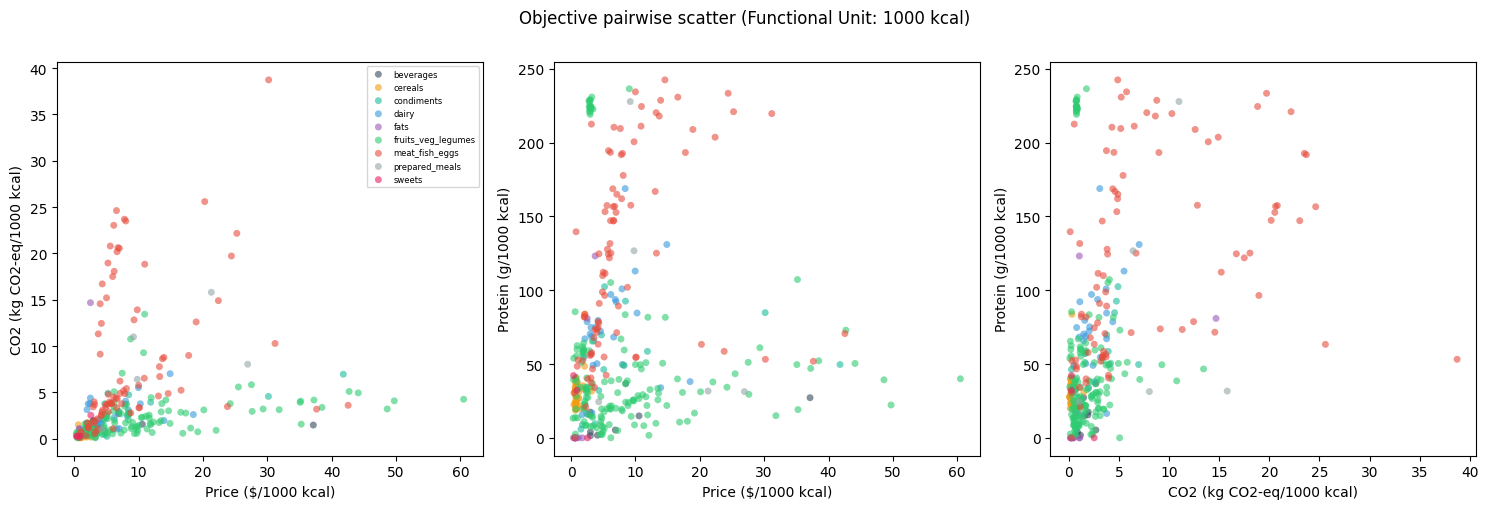


Objective correlations (per-1000-kcal basis):
                      price_per_1000kcal  co2_per_1000kcal  \
price_per_1000kcal                 1.000             0.295   
co2_per_1000kcal                   0.295             1.000   
protein_per_1000kcal               0.086             0.403   

                      protein_per_1000kcal  
price_per_1000kcal                   0.086  
co2_per_1000kcal                     0.403  
protein_per_1000kcal                 1.000  

Interpretation: energy-dense foods (fats/oils) cluster near zero on price & CO2 axes.
Lean meats/fish push high on protein axis. Legumes should appear as Pareto heroes.


In [90]:
# Pairwise scatter matrix of three objectives (all on per-1000-kcal basis)
obj_cols = ["price_per_1000kcal", "co2_per_1000kcal", "protein_per_1000kcal"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [(0, 1), (0, 2), (1, 2)]
labels = [
    "Price ($/1000 kcal)",
    "CO2 (kg CO2-eq/1000 kcal)",
    "Protein (g/1000 kcal)",
]
for ax, (i, j) in zip(axes, pairs):
    for grp, grp_df in df.groupby("group_en"):
        ax.scatter(
            grp_df[obj_cols[i]], grp_df[obj_cols[j]],
            color=PALETTE.get(grp, PALETTE["default"]),
            alpha=0.6, edgecolors="none", s=25, label=grp,
        )
    ax.set_xlabel(labels[i]); ax.set_ylabel(labels[j])
axes[0].legend(fontsize=6, bbox_to_anchor=(1, 1))
plt.suptitle("Objective pairwise scatter (Functional Unit: 1000 kcal)", y=1.01)
plt.tight_layout()
plt.show()

corr = df[obj_cols].corr()
print("\nObjective correlations (per-1000-kcal basis):")
print(corr.round(3))
print("\nInterpretation: energy-dense foods (fats/oils) cluster near zero on price & CO2 axes.")
print("Lean meats/fish push high on protein axis. Legumes should appear as Pareto heroes.")


## 3. Pareto Function

**Why normalize?** The three objectives have very different scales
(CO2: 0.3–45 kg/kg; price: 0.5–30 $/kg; protein: 0–40 g/100kcal).
Without normalization, the highest-magnitude objective would dominate
the dominance check. Min-max scaling puts all objectives on [0,1].

Protein is a maximize objective → invert by computing `1 - normalized_protein`
so all three objectives point in the "minimize" direction before calling
`is_pareto_efficient`.


In [91]:
def is_pareto_efficient(costs):
    """
    Find Pareto-efficient rows where all objectives are to be minimized.

    costs: (n_points, n_objectives) ndarray — caller must:
       1. normalize each objective to [0, 1] min-max
       2. invert any maximize objectives (use 1 - normalized)
    Returns boolean mask of length n_points.
    """
    n = len(costs)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < costs[i], axis=1)
            is_efficient[i] = True
    return is_efficient


def run_pareto(df, weights=(1, 1, 1)):
    """
    Run Pareto analysis on Functional-Unit objectives (per 1000 kcal).

    Objectives:
      - MINIMIZE price_per_1000kcal  (cost of energy)
      - MINIMIZE co2_per_1000kcal    (carbon footprint of energy)
      - MAXIMIZE protein_per_1000kcal (protein density) → inverted before dominance check

    weights: (w_price, w_co2, w_protein) — higher weight = objective counts more.
    """
    price = df["price_per_1000kcal"].values
    co2   = df["co2_per_1000kcal"].values
    prot  = df["protein_per_1000kcal"].values

    def norm(x):
        xmin, xmax = x.min(), x.max()
        return (x - xmin) / (xmax - xmin + 1e-9)

    costs = np.column_stack([
        norm(price) * weights[0],
        norm(co2)   * weights[1],
        (1 - norm(prot)) * weights[2],  # invert: maximize protein → minimize
    ])
    mask = is_pareto_efficient(costs)
    return df[mask].copy()


## 4. Main Pareto Run (Equal Weights 1:1:1)

In [92]:
df_pareto = run_pareto(df, weights=(1, 1, 1))
print(f"Pareto front size: {len(df_pareto)} / {len(df)} total foods")
print("\nFull Pareto front (sorted by protein density per 1000 kcal):")
cols_show = [
    "description",
    "price_per_1000kcal",
    "co2_per_1000kcal",
    "protein_per_1000kcal",
    "group_en",
]
print(df_pareto.sort_values("protein_per_1000kcal", ascending=False)[cols_show].to_string(index=False))


Pareto front size: 15 / 357 total foods

Full Pareto front (sorted by protein density per 1000 kcal):
                                description  price_per_1000kcal  co2_per_1000kcal  protein_per_1000kcal           group_en
Tuna, ahi or yellowfin, frozen, wild caught           14.576383          4.888607            242.467078     meat_fish_eggs
             Mahi mahi, frozen, wild caught            9.045286          1.772755            236.451981 fruits_veg_legumes
     Beans, Dry, Flor de Mayo (0% moisture)            3.224138          0.850010            230.830196 fruits_veg_legumes
       Beans, Dry, Medium Red (0% moisture)            2.922454          0.770474            228.987069 fruits_veg_legumes
              Beans, Dry, Tan (0% moisture)            2.770683          0.730461            228.162779 fruits_veg_legumes
                          Egg, white, dried            3.159870          0.550532            212.500000     meat_fish_eggs
                       Flour, soy, de

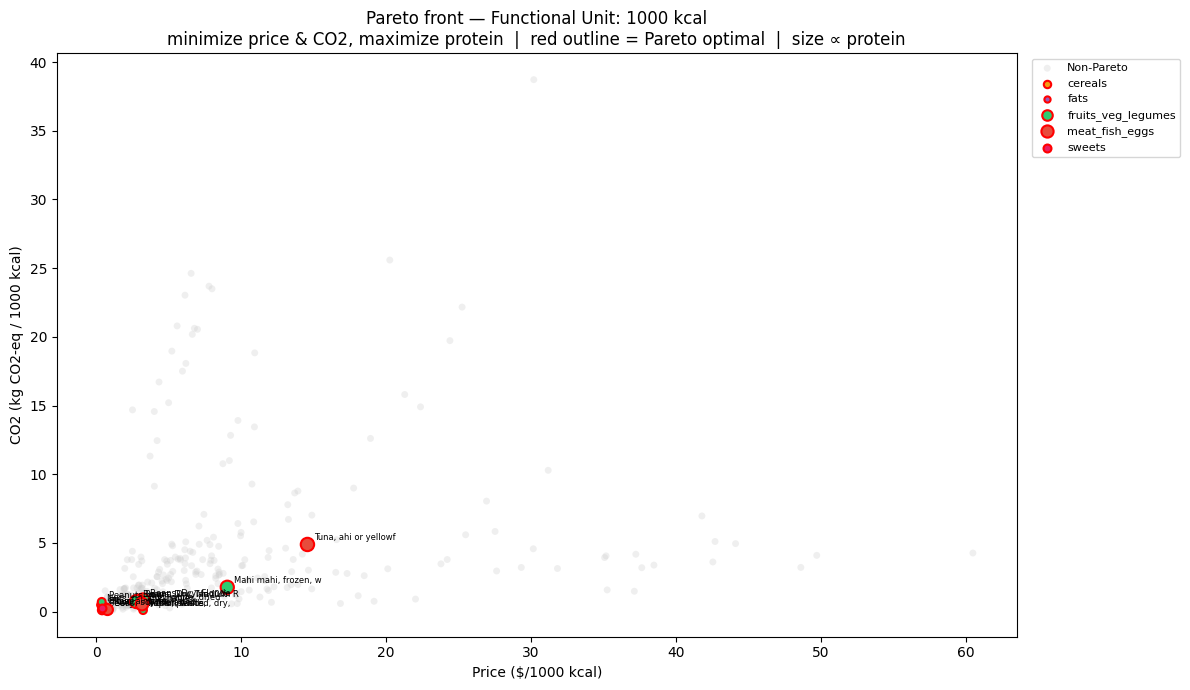

In [93]:
# Main Pareto scatter: price vs CO2 (both per 1000 kcal), size ∝ protein density
fig, ax = plt.subplots(figsize=(12, 7))

non_pareto = df[~df.index.isin(df_pareto.index)]
ax.scatter(
    non_pareto["price_per_1000kcal"], non_pareto["co2_per_1000kcal"],
    c="#cccccc", alpha=0.3, s=25, edgecolors="none", label="Non-Pareto",
)

for grp, grp_df in df_pareto.groupby("group_en"):
    sizes = grp_df["protein_per_1000kcal"] * 0.3 + 20  # scale: g/1000kcal → point size
    ax.scatter(
        grp_df["price_per_1000kcal"], grp_df["co2_per_1000kcal"],
        color=PALETTE.get(grp, PALETTE["default"]),
        s=sizes, edgecolors="red", linewidths=1.5, zorder=3, label=grp,
    )
    for _, r in grp_df.iterrows():
        ax.annotate(
            r["description"][:20],
            (r["price_per_1000kcal"], r["co2_per_1000kcal"]),
            fontsize=6, xytext=(5, 3), textcoords="offset points",
        )

ax.set_xlabel("Price ($/1000 kcal)")
ax.set_ylabel("CO2 (kg CO2-eq / 1000 kcal)")
ax.set_title(
    "Pareto front — Functional Unit: 1000 kcal\n"
    "minimize price & CO2, maximize protein  |  red outline = Pareto optimal  |  size ∝ protein"
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


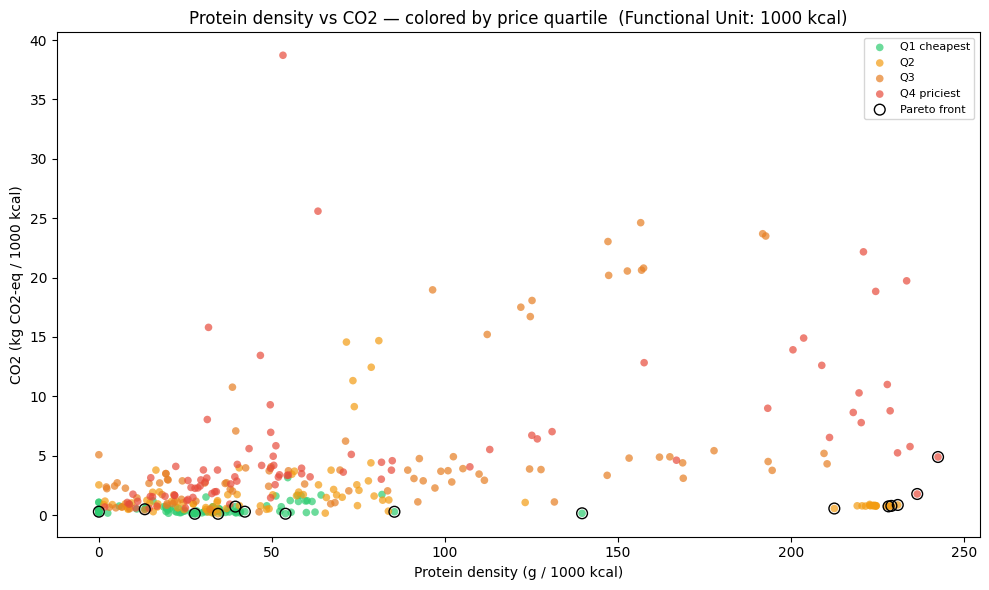

In [94]:
# Secondary scatter: protein vs CO2 (per 1000 kcal), color by price quartile
df_copy = df.copy()
df_copy["price_quartile"] = pd.qcut(
    df_copy["price_per_1000kcal"], 4,
    labels=["Q1 cheapest", "Q2", "Q3", "Q4 priciest"],
)
colors_q = {
    "Q1 cheapest": "#2ecc71",
    "Q2": "#f39c12",
    "Q3": "#e67e22",
    "Q4 priciest": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(10, 6))
for q, qdf in df_copy.groupby("price_quartile"):
    ax.scatter(
        qdf["protein_per_1000kcal"], qdf["co2_per_1000kcal"],
        color=colors_q[q], alpha=0.7, label=q, edgecolors="none", s=30,
    )

# Outline Pareto points
ax.scatter(
    df_pareto["protein_per_1000kcal"], df_pareto["co2_per_1000kcal"],
    facecolors="none", edgecolors="black", s=60, zorder=3, label="Pareto front",
)

ax.set_xlabel("Protein density (g / 1000 kcal)")
ax.set_ylabel("CO2 (kg CO2-eq / 1000 kcal)")
ax.set_title("Protein density vs CO2 — colored by price quartile  (Functional Unit: 1000 kcal)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Sensitivity Analysis

### Why these four scenarios?

The four weighting schemes represent four distinct real-world decision contexts that a user of this analysis might have:

- **Balanced** (equal weights): the neutral baseline — no prior assumption about which objective matters more. Used as the primary result in Section 4.
- **Eco-conscious** (CO2 weight = 0.60): represents a consumer whose primary constraint is minimizing environmental footprint, willing to pay more and accept lower protein if CO2 is minimized. Relevant for sustainability-focused dietary guidelines.
- **High Protein Budget** (protein weight = 0.50, price weight = 0.40, CO2 weight = 0.10): represents an athlete or bodybuilder on a budget who largely ignores environmental cost. CO2 is nearly irrelevant to this decision.
- **Budget** (price weight = 0.70): represents a food-insecure household or institutional food service where cost is the dominant constraint. Protein and CO2 are secondary.

Together, these four scenarios span the realistic space of priorities without cherry-picking. A food that appears on all four fronts is genuinely hard to beat regardless of values — that is a stronger claim than optimality under a single weighting.

In [95]:
# Sensitivity Analysis: named scenarios with explicit per-1000kcal column weights
# weights order: (w_price_per_1000kcal, w_co2_per_1000kcal, w_protein_per_1000kcal)
SCENARIOS = {
    "Balanced": {
        "weights": (0.33, 0.33, 0.34),
        "label": "Equal weight on cost, CO2, and protein",
    },
    "Eco-conscious": {
        "weights": (0.20, 0.60, 0.20),
        "label": "Planet first — high CO2 penalty",
    },
    "High Protein Budget": {
        "weights": (0.40, 0.10, 0.50),
        "label": "Maximize protein at low cost, ignore CO2",
    },
    "Budget": {
        "weights": (0.70, 0.15, 0.15),
        "label": "Pure cost minimization",
    },
}

pareto_sets = {}
for name, cfg in SCENARIOS.items():
    w = cfg["weights"]
    pf = run_pareto(df, weights=w)
    pareto_sets[name] = set(pf["description"])
    print(f"{name:22s} ({cfg['label']})")
    print(f"  weights=(price={w[0]}, co2={w[1]}, protein={w[2]})  →  {len(pf):3d} foods on front")
    top5 = pf.nlargest(5, "protein_per_1000kcal")["description"].tolist()
    print("  Top 5 by protein density:")
    for t in top5:
        print(f"    {t}")
    print()


Balanced               (Equal weight on cost, CO2, and protein)
  weights=(price=0.33, co2=0.33, protein=0.34)  →   15 foods on front
  Top 5 by protein density:
    Tuna, ahi or yellowfin, frozen, wild caught
    Mahi mahi, frozen, wild caught
    Beans, Dry, Flor de Mayo (0% moisture)
    Beans, Dry, Medium Red (0% moisture)
    Beans, Dry, Tan (0% moisture)

Eco-conscious          (Planet first — high CO2 penalty)
  weights=(price=0.2, co2=0.6, protein=0.2)  →   15 foods on front
  Top 5 by protein density:
    Tuna, ahi or yellowfin, frozen, wild caught
    Mahi mahi, frozen, wild caught
    Beans, Dry, Flor de Mayo (0% moisture)
    Beans, Dry, Medium Red (0% moisture)
    Beans, Dry, Tan (0% moisture)

High Protein Budget    (Maximize protein at low cost, ignore CO2)
  weights=(price=0.4, co2=0.1, protein=0.5)  →   15 foods on front
  Top 5 by protein density:
    Tuna, ahi or yellowfin, frozen, wild caught
    Mahi mahi, frozen, wild caught
    Beans, Dry, Flor de Mayo (0% moist

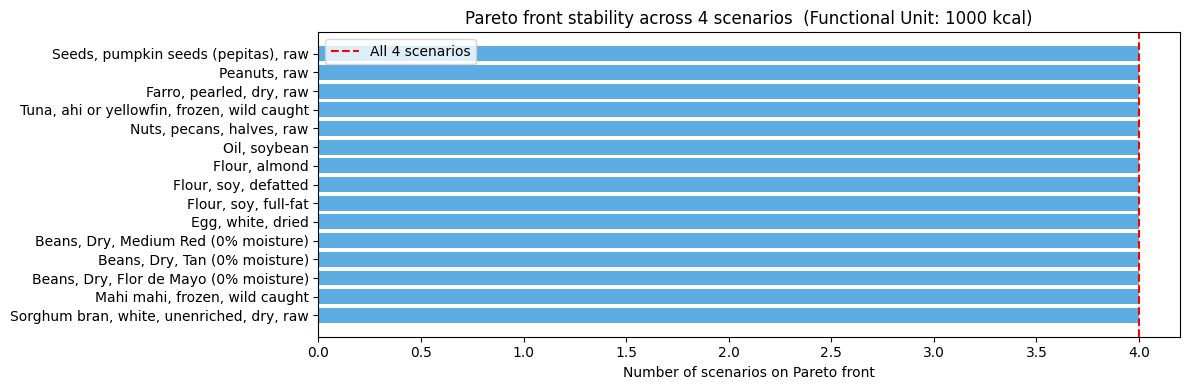


Robust foods (on Pareto front in ALL 4 scenarios): 15
['Seeds, pumpkin seeds (pepitas), raw', 'Peanuts, raw', 'Farro, pearled, dry, raw', 'Tuna, ahi or yellowfin, frozen, wild caught', 'Nuts, pecans, halves, raw', 'Oil, soybean', 'Flour, almond', 'Flour, soy, defatted', 'Flour, soy, full-fat', 'Egg, white, dried', 'Beans, Dry, Medium Red (0% moisture)', 'Beans, Dry, Tan (0% moisture)', 'Beans, Dry, Flor de Mayo (0% moisture)', 'Mahi mahi, frozen, wild caught', 'Sorghum bran, white, unenriched, dry, raw']


In [96]:
# Stability: how many scenarios does each food appear in?
all_foods_on_any_front = set().union(*pareto_sets.values())
stability = {
    food: sum(food in ps for ps in pareto_sets.values())
    for food in all_foods_on_any_front
}
stab_df = pd.Series(stability).sort_values(ascending=False).reset_index()
stab_df.columns = ["food", "n_scenarios"]

fig, ax = plt.subplots(figsize=(12, max(4, len(stab_df) * 0.25)))
ax.barh(stab_df["food"], stab_df["n_scenarios"], color="#3498db", alpha=0.8)
ax.axvline(len(SCENARIOS), ls="--", color="red", label=f"All {len(SCENARIOS)} scenarios")
ax.set_xlabel("Number of scenarios on Pareto front")
ax.set_title(f"Pareto front stability across {len(SCENARIOS)} scenarios  (Functional Unit: 1000 kcal)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

robust = stab_df[stab_df["n_scenarios"] == len(SCENARIOS)]
print(f"\nRobust foods (on Pareto front in ALL {len(SCENARIOS)} scenarios): {len(robust)}")
print(robust["food"].tolist())


## 6. Results & Interpretation

In [97]:
df_pareto_equal = run_pareto(df, weights=(1, 1, 1))
group_counts = df_pareto_equal["group_en"].value_counts()
print("Food groups on Pareto front (equal weights, Functional Unit: 1000 kcal):")
print(group_counts.to_string())

def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

df_pareto_equal = df_pareto_equal.copy()
# Composite score: lower is better for price & CO2, higher is better for protein
df_pareto_equal["norm_score"] = (
    norm(df_pareto_equal["price_per_1000kcal"]) +
    norm(df_pareto_equal["co2_per_1000kcal"]) +
    (1 - norm(df_pareto_equal["protein_per_1000kcal"]))
)
best = df_pareto_equal.loc[df_pareto_equal["norm_score"].idxmin()]
print(f"\nBest single food (lowest sum of normalized objectives, per 1000 kcal):")
print(f"  {best['description']}")
print(
    f"  Price=${best['price_per_1000kcal']:.2f}/1000kcal  "
    f"| CO2={best['co2_per_1000kcal']:.3f} kg/1000kcal  "
    f"| Protein={best['protein_per_1000kcal']:.1f} g/1000kcal"
)

# Tradeoff analysis
lowest_price = df_pareto_equal.nsmallest(1, "price_per_1000kcal").iloc[0]
lowest_co2   = df_pareto_equal.nsmallest(1, "co2_per_1000kcal").iloc[0]
print(f"\nTradeoff analysis:")
print(
    f"  Lowest price ({lowest_price['description'][:40]}): "
    f"protein={lowest_price['protein_per_1000kcal']:.1f} g/1000kcal  "
    f"co2={lowest_price['co2_per_1000kcal']:.3f}"
)
print(
    f"  Lowest CO2   ({lowest_co2['description'][:40]}): "
    f"protein={lowest_co2['protein_per_1000kcal']:.1f} g/1000kcal  "
    f"price={lowest_co2['price_per_1000kcal']:.2f}"
)
print(
    f"  Best balanced ({best['description'][:40]}): "
    f"protein={best['protein_per_1000kcal']:.1f} g/1000kcal"
)


Food groups on Pareto front (equal weights, Functional Unit: 1000 kcal):
group_en
fruits_veg_legumes    9
meat_fish_eggs        3
sweets                1
fats                  1
cereals               1

Best single food (lowest sum of normalized objectives, per 1000 kcal):
  Beans, Dry, Tan (0% moisture)
  Price=$2.77/1000kcal  | CO2=0.730 kg/1000kcal  | Protein=228.2 g/1000kcal

Tradeoff analysis:
  Lowest price (Nuts, pecans, halves, raw): protein=13.3 g/1000kcal  co2=0.488
  Lowest CO2   (Farro, pearled, dry, raw): protein=34.4 g/1000kcal  price=3.24
  Best balanced (Beans, Dry, Tan (0% moisture)): protein=228.2 g/1000kcal


## 7. Save

In [98]:
df_pareto_equal.to_csv("foundation_pareto_front.csv", index=False)
print("Saved: foundation_pareto_front.csv")
print("Shape:", df_pareto_equal.shape)
print("\nNew Functional Unit columns included in output:")
for c in ["kcal_per_kg", "price_per_1000kcal", "co2_per_1000kcal", "protein_per_1000kcal"]:
    print(f"  {c}")


Saved: foundation_pareto_front.csv
Shape: (15, 38)

New Functional Unit columns included in output:
  kcal_per_kg
  price_per_1000kcal
  co2_per_1000kcal
  protein_per_1000kcal
